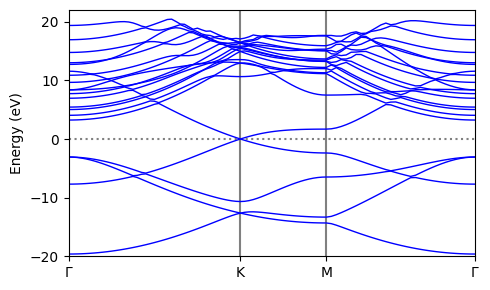

In [4]:
import numpy as np
import matplotlib.pyplot as plt


bands_file = "gr.bands.gnu"   # file from plotband.x
efermi     = -4.2071          # Fermi energy in eV (from your scf)

# number of k-points between high-symmetry points
# from your K_POINTS (crystal_b):
#   Γ 40  K 20  M 30  Γ 0  --> total = 40 + 20 + 30 = 90
n_GK = 40
n_KM = 20
n_MG = 30


data = np.loadtxt(bands_file)

# all k-values (repeated for each band)
k_all = data[:, 0]
E_all = data[:, 1]

# unique k-path (Γ→K→M→Γ)
k = np.unique(k_all)
nk = len(k)

# number of bands
nbands = len(E_all) // nk

# reshape energies: shape = (nbands, nk)
bands = E_all.reshape(nbands, nk)

# -------------------------------------------------------
# 3) HIGH-SYMMETRY POINTS
# -------------------------------------------------------
G1 = k[0]
K  = k[n_GK]
M  = k[n_GK + n_KM]
G2 = k[n_GK + n_KM + n_MG]

# -------------------------------------------------------
# 4) PLOT
# -------------------------------------------------------
plt.figure(figsize=(5,3))

# dotted Fermi level at 0 eV
plt.axhline(0.0, c='gray', ls=':')

# vertical lines at K and M
plt.axvline(K, c='gray')
plt.axvline(M, c='gray')

# plot each band
for b in range(nbands):
    plt.plot(k, bands[b, :] - efermi, c='b', lw=1)

plt.xlabel('')
plt.ylabel('Energy (eV)')
plt.xlim(G1, G2)
plt.ylim(-20, 22)

plt.xticks([G1, K, M, G2], [r'$\Gamma$', 'K', 'M', r'$\Gamma$'])

plt.tick_params(axis='x', which='minor', bottom=False, top=False)

plt.tight_layout()
plt.savefig("graphene_band_structure.jpg", dpi=300, bbox_inches="tight")
plt.show()